In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [2]:
df = pd.read_csv(r"C:\Users\PRATHAM\OneDrive\Desktop\Resume Projects\Churn Prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [5]:
df.shape


(7043, 21)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df = df.drop(columns=["customerID"])

CustomerID is a unique identifier and carries no predictive information

In [9]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
print(df["gender"].unique())

['Female' 'Male']


In [11]:
print(df["SeniorCitizen"].unique())

[0 1]


In [12]:
numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())
    print("-"*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [13]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df[df["TotalCharges"]==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [15]:
len(df[df["TotalCharges"]==" "])

11

In [16]:
df["TotalCharges"]=df["TotalCharges"].replace({" ":"0.0"})

In [17]:
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [18]:
print(df['Churn'].value_counts())


Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Insights:**
1. Customer ID removed as it is not required for modelling
2. No mmissing values in the dataset
3. Missing values in the TotalCharges column were replaced with 0
4. Class imbalance identified in the target

EDA NOW

In [19]:
df.shape

(7043, 20)

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Numerical Features Analysis

In [21]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

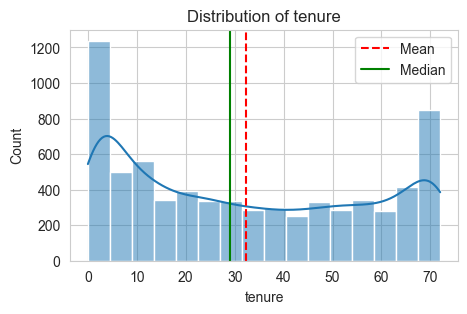

In [22]:
plot_histogram(df,"tenure")

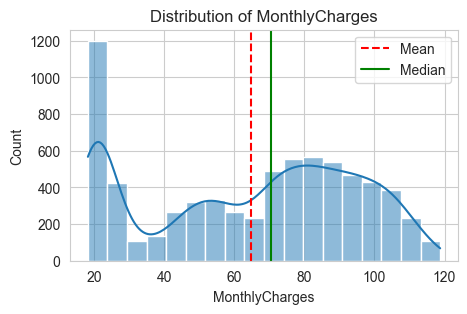

In [23]:
plot_histogram(df,"MonthlyCharges")

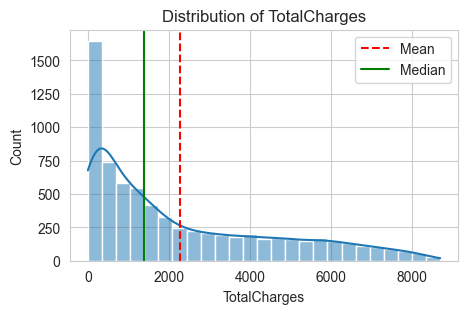

In [24]:
plot_histogram(df,"TotalCharges")

In [25]:
def plot_boxplot(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show

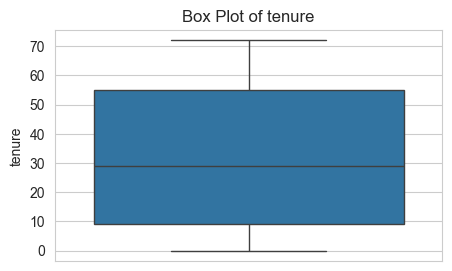

In [26]:
plot_boxplot(df, "tenure")

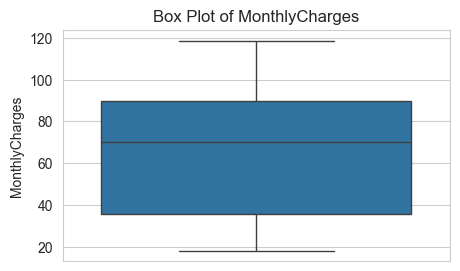

In [27]:
plot_boxplot(df, "MonthlyCharges")

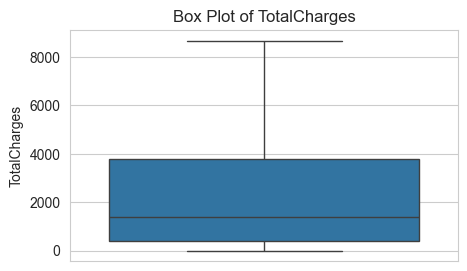

In [28]:
plot_boxplot(df, "TotalCharges")

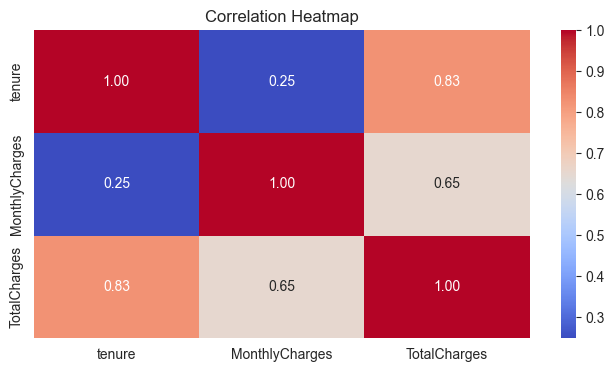

In [29]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

“Tenure is strongly correlated with TotalCharges, which guided feature selection.”

Categorical features - Analysis

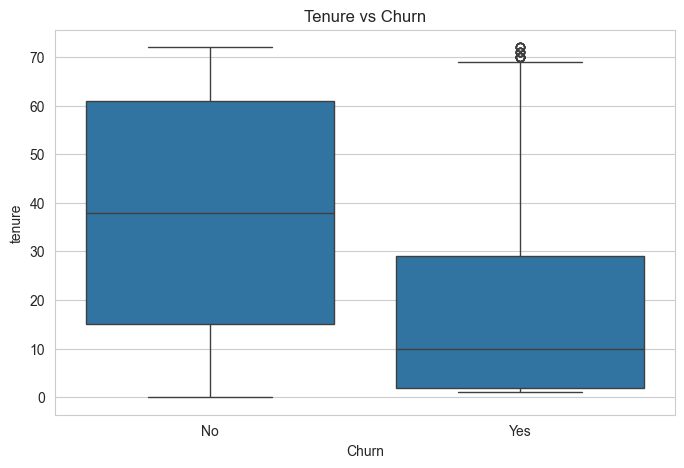

In [30]:
# Tenure vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


Insight:
Customers with short tenure churn more.

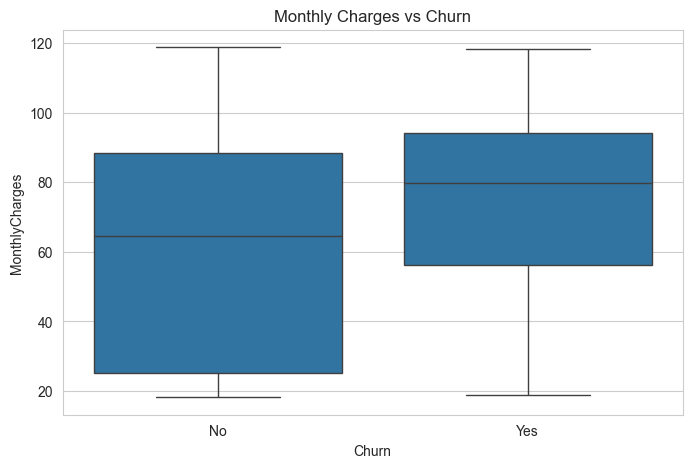

In [31]:
# Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


Insight:
Higher monthly charges → higher churn risk.

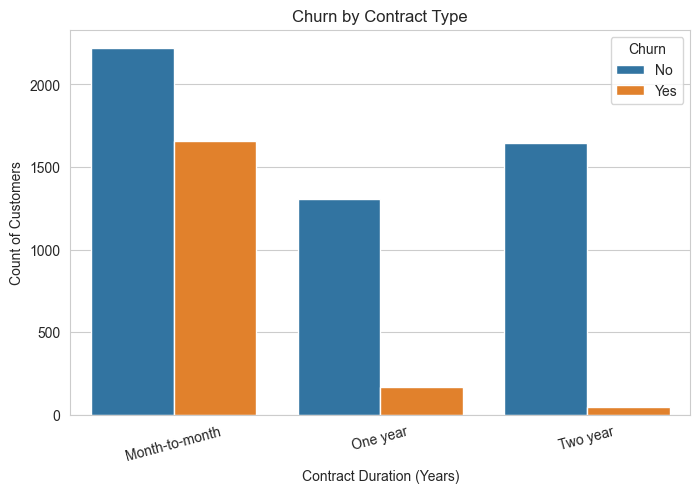

In [32]:
# Contract Type
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Duration (Years)")  # X-axis label
plt.ylabel("Count of Customers")         # Y-axis label
plt.xticks(rotation=15)
plt.show()


 Strong Business Insight:

Month-to-month customers churn significantly more.

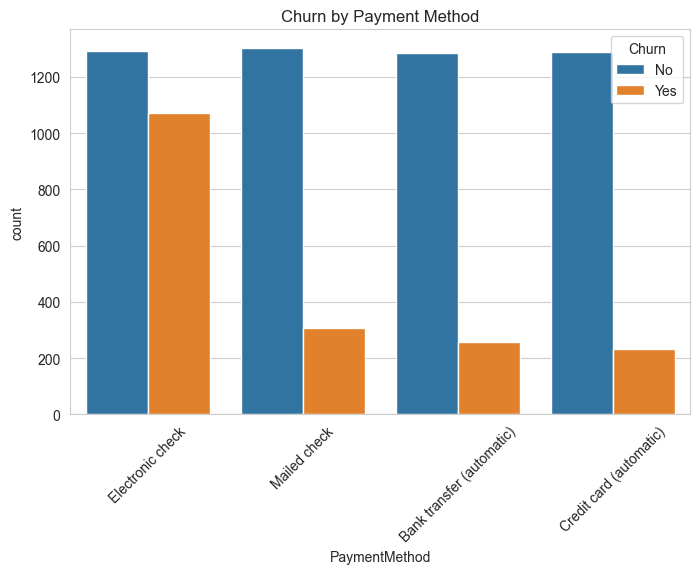

In [33]:
# Payment Method
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()


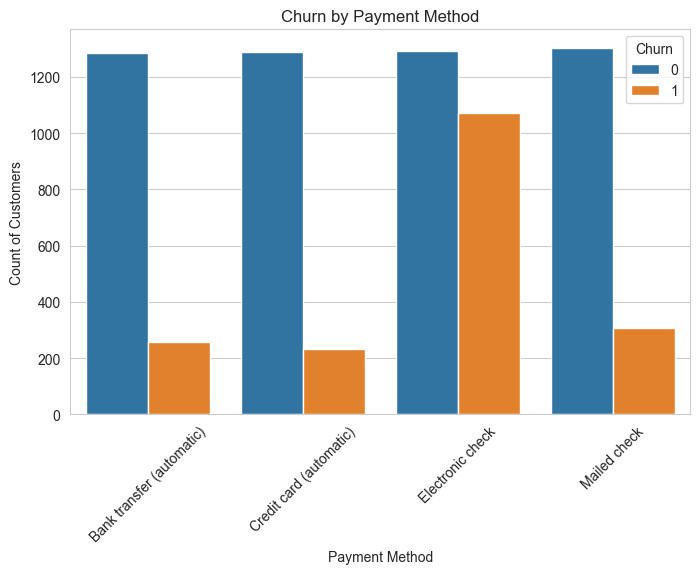

In [46]:
# churn by payment method
from sklearn.preprocessing import LabelEncoder
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count of Customers")

# Get original labels from the encoder
original_labels = encoders['PaymentMethod'].classes_
plt.xticks(ticks=range(len(original_labels)), labels=original_labels, rotation=45)

plt.show()

Insight:
Electronic check users show higher churn.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


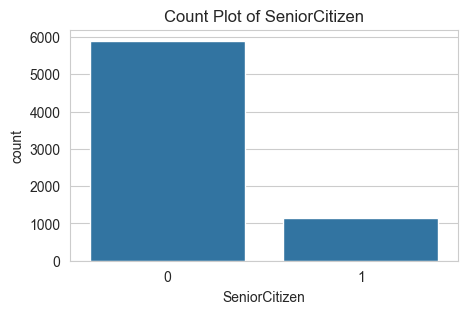

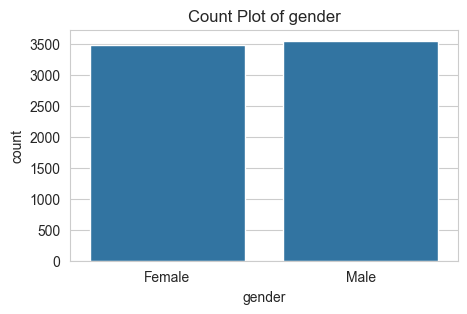

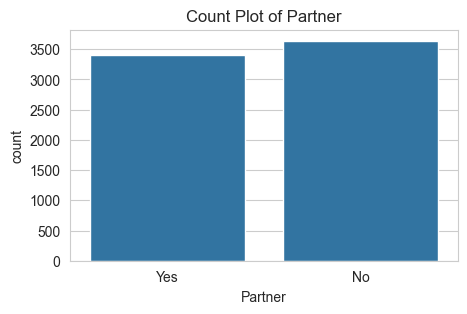

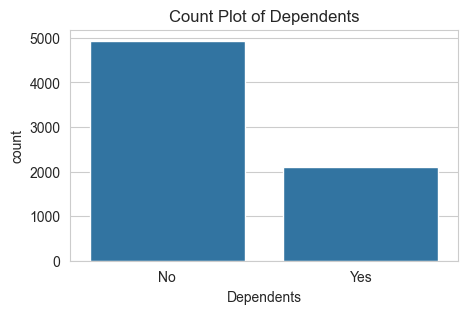

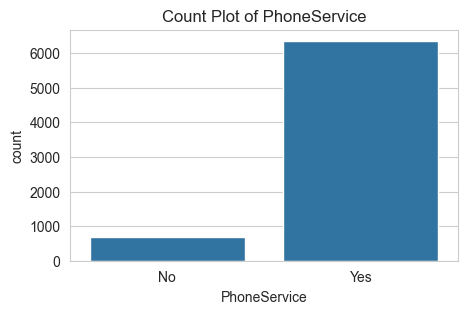

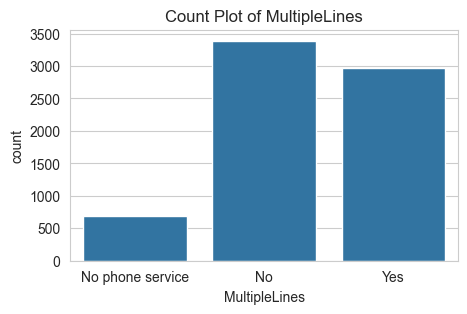

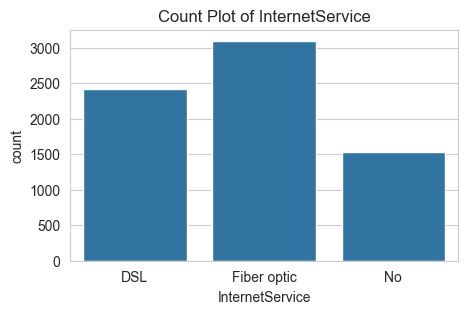

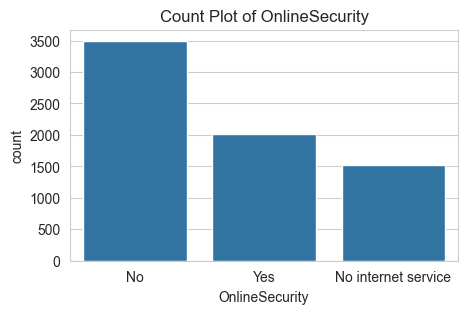

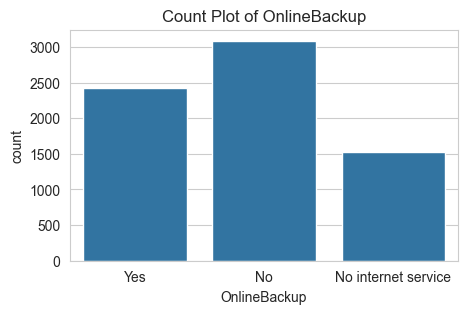

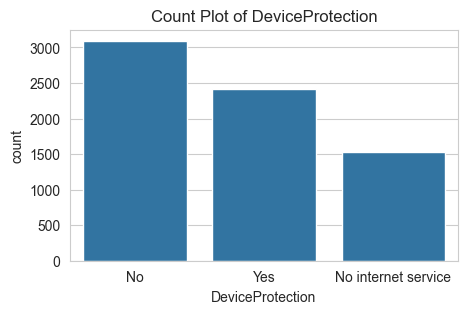

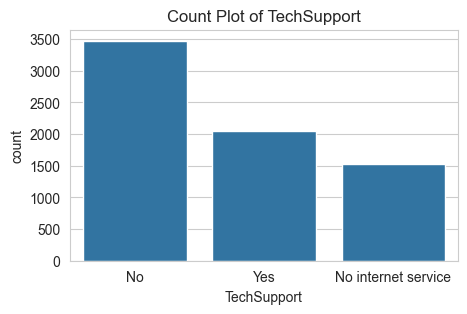

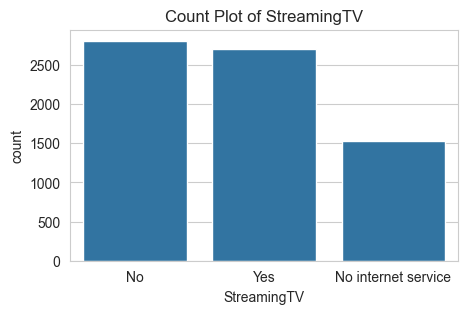

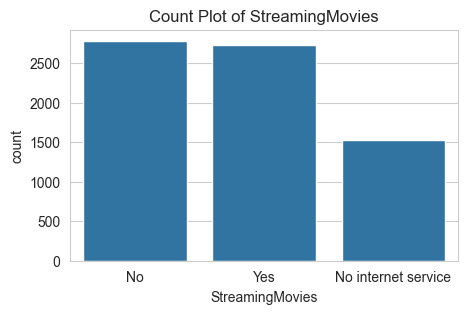

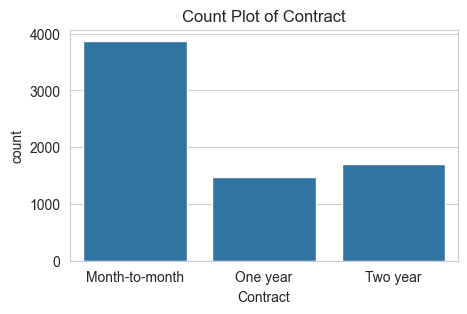

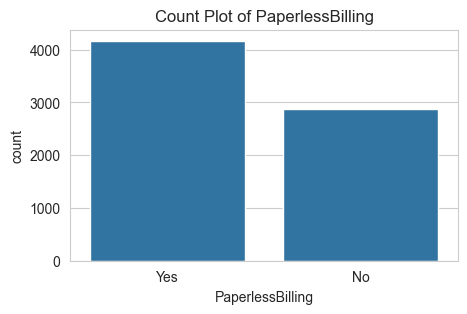

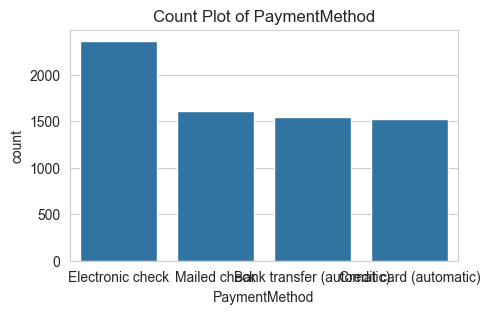

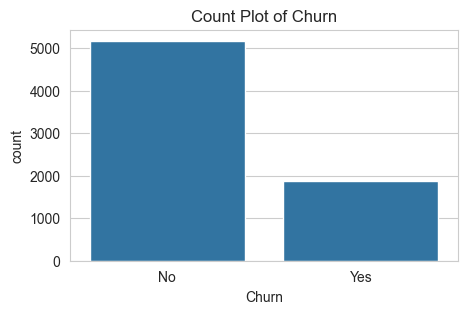

In [38]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col])
  plt.title(f"Count Plot of {col}")
  plt.show()

DATA preprocessing

### Key Insights from EDA
- Customers on month-to-month contracts show the highest churn.
- Short-tenure customers are significantly more likely to churn.
- Higher monthly charges increase churn probability.
- Payment method influences customer retention behavior.


In [39]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

C:\Users\PRATHAM\AppData\Local\Temp\ipykernel_3500\2364848822.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})


In [41]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


Label encoding for categorical features

In [42]:
object_columns = df.select_dtypes(include="object").columns

In [43]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.drop('Churn')

categorical_cols, numerical_cols


(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))

In [44]:
print(object_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [45]:
# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder

In [147]:
df_encoded = df.copy()

encoders = {}

for column in object_columns:
    label_encoder = LabelEncoder()
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])
    encoders[column] = label_encoder


Label Encoding was used since tree-based models do not assume ordinal relationships and handle encoded categories effectively.

In [47]:
# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)

    


In [150]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)


In [48]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [146]:
df_encoded.to_csv("../data/processed/X_full.csv", index=False)


NameError: name 'df_encoded' is not defined

In [49]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


Train_Test Splliting Data 

In [50]:
X = df.iloc[:, :-1]  # All rows, all columns except last
y = df.iloc[:, -1]   # All rows, last column only

In [51]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60


In [52]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


SMOTE (Synthetic Minority Over-sampling Technique)

In [55]:
smote = SMOTE(random_state=42)

In [56]:
 X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [57]:
print(y_train_smote.shape)

(8276,)


In [58]:
print(y_train_smote.value_counts()) #oversampling achieved

Churn
0    4138
1    4138
Name: count, dtype: int64


MODEL Training

In [59]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [60]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]


In [61]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.794180269694819
ROC-AUC: 0.8372853416419099
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1036
           1       0.61      0.64      0.62       373

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.80      1409



In [62]:
# dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [63]:
# dictionary to store the cross validation results
cv_scores = {}

# perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*70)

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.78
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.84
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.83
----------------------------------------------------------------------


In [64]:
cv_scores

{'Decision Tree': array([0.68115942, 0.71903323, 0.81752266, 0.84350453, 0.84350453]),
 'Random Forest': array([0.72705314, 0.76676737, 0.90453172, 0.89244713, 0.89848943]),
 'XGBoost': array([0.71074879, 0.75226586, 0.90271903, 0.89123867, 0.89909366])}

Random Forest gives the highest accuracy compared to other models with default parameters

In [65]:
rfc = RandomForestClassifier(random_state=42)

In [66]:
rfc.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Model Evaluation

In [67]:
# evaluate on test data
y_test_pred = rfc.predict(X_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confsuion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.7771469127040455
Confsuion Matrix:
 [[880 156]
 [158 215]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



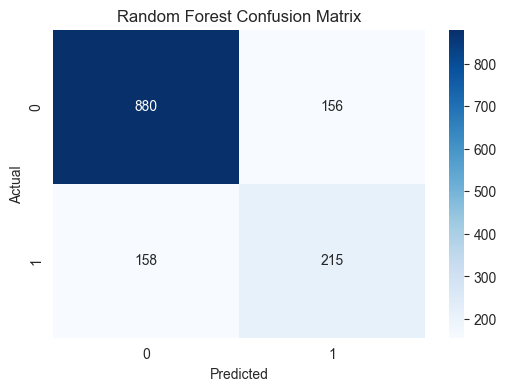

In [68]:
cm = confusion_matrix(y_test,  y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


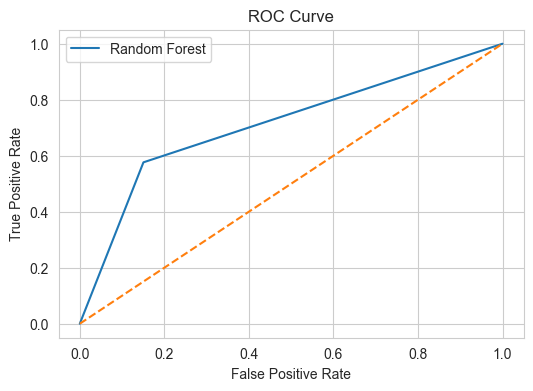

In [69]:
fpr, tpr, _ = roc_curve(y_test,y_test_pred)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [70]:
feature_importance = pd.Series(
    rfc.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)


TotalCharges       0.140117
MonthlyCharges     0.138997
Contract           0.129169
tenure             0.121609
OnlineSecurity     0.084711
TechSupport        0.075400
PaymentMethod      0.044756
OnlineBackup       0.037208
Dependents         0.030504
InternetService    0.029366
dtype: float64

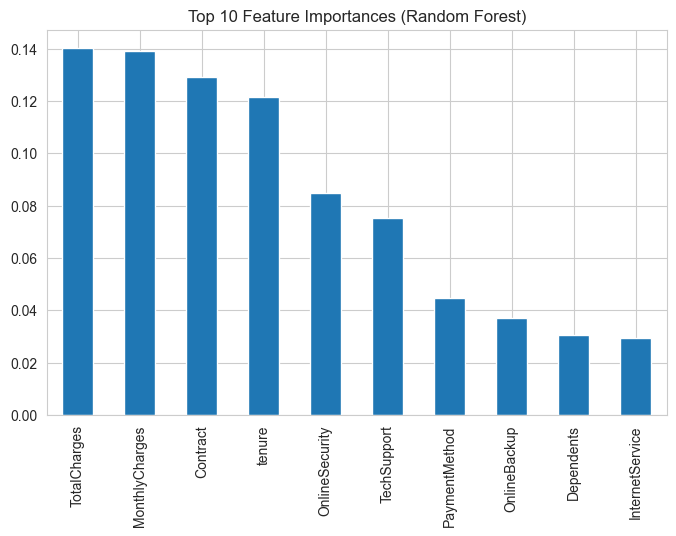

In [71]:
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


Contract type, tenure, and monthly charges were the strongest churn predictors

In [72]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [73]:
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]


In [74]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.808374733853797
Gradient Boosting ROC-AUC: 0.8590513627376898
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.68      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



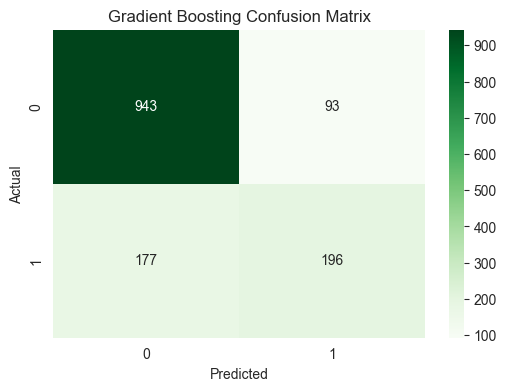

In [75]:
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()


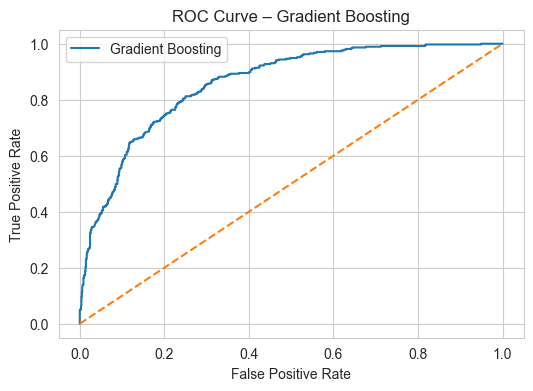

In [76]:
fpr, tpr, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Gradient Boosting")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Gradient Boosting")
plt.legend()
plt.show()


In [77]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "Accuracy": [0.777, accuracy_score(y_test, y_pred_gb)],
    "ROC-AUC": [0.71, roc_auc_score(y_test, y_prob_gb)]
})

comparison


,Model,Accuracy,ROC-AUC
0,Random Forest,0.777000,0.710000
1,Gradient Boosting,0.808375,0.859051


In [78]:
# save the trained model as a pickle file
model_data = {"model": rfc, "features_names": X.columns.tolist()}


with open("customer_churn_model.pkl", "wb") as f:
  pickle.dump(model_data, f)

In [79]:
# load the saved model and the feature names

with open("customer_churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [80]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [81]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [82]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}


input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


# encode categorical featires using teh saved encoders
for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

# make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

# results
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediciton Probability: {pred_prob}")

[0]
Prediction: No Churn
Prediciton Probability: [[0.83 0.17]]


In [83]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [84]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(pd.Series(y_train_smote).value_counts())


Churn
0    4138
1    4138
Name: count, dtype: int64


In [85]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled  = scaler.transform(X_test)


StandardScaler was fitted only on training data to prevent data leakage

In [86]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train_scaled, y_train_smote)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [87]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]


In [88]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.7643718949609652
ROC-AUC: 0.8395807239641019
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.54      0.78      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.78      1409



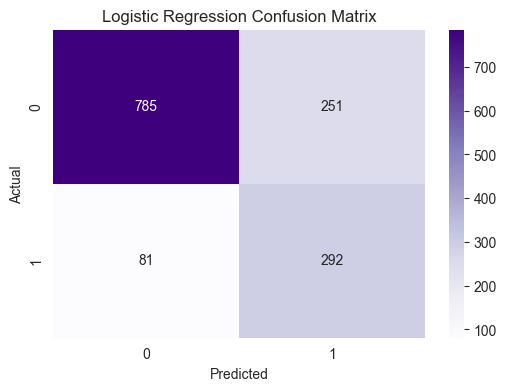

In [89]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


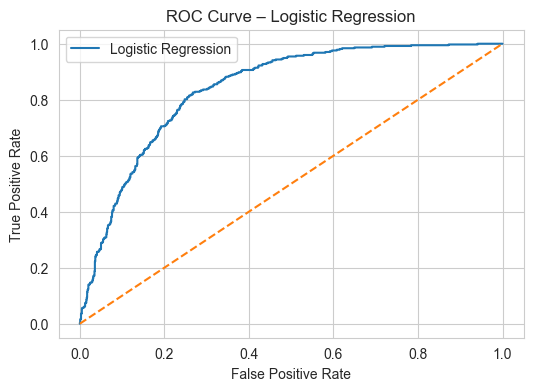

In [90]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()


In [91]:
coef_df = pd.Series(
    lr.coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

coef_df.head(10)


tenure           -1.748016
TotalCharges      1.474650
Contract         -0.826719
MonthlyCharges    0.675214
PhoneService     -0.492961
OnlineSecurity   -0.350077
TechSupport      -0.327378
Dependents       -0.311061
gender           -0.252383
OnlineBackup     -0.243974
dtype: float64

In [119]:
from xgboost import XGBClassifier

In [120]:
# Calculate scale_pos_weight
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
scale_pos_weight


np.float64(2.766042780748663)

I used scale_pos_weight to penalize misclassification of churners instead of oversampling.

In [121]:
import xgboost as xgb
from xgboost import XGBClassifier  # For classification tasks
from xgboost import XGBRegressor    # For regression tasks

# Example:
model = XGBClassifier()
model.fit(X_train, y_train)

# Basic usage:
# model = xgb.train(params, dtrain)
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)


xgb_base.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Hyperparameter Tuning 

In [122]:
param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}


In [123]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,                 # enough for placements
    scoring='roc_auc',         # IMPORTANT
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [200, 300, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


“I optimized XGBoost using RandomizedSearchCV with ROC-AUC as the scoring metric due to class imbalance.

In [124]:
random_search.best_params_


{'subsample': 0.8,
 'n_estimators': 200,
 'max_depth': 3,
 'learning_rate': 0.03,
 'colsample_bytree': 0.8}

In [125]:
from sklearn.metrics import classification_report

y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))
print(classification_report(y_test, y_pred_tuned))


ROC-AUC: 0.862638059353877
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.84      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



Threshold Tuning 

In [126]:
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]


In [127]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

results = []

for t in thresholds:
    y_pred_thresh = (y_prob_tuned >= t).astype(int)
    
    results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred_thresh),
        "Recall": recall_score(y_test, y_pred_thresh),
        "F1-Score": f1_score(y_test, y_pred_thresh)
    })

threshold_df = pd.DataFrame(results)
threshold_df


,Threshold,Precision,Recall,F1-Score
0,0.20,0.382729,0.962466,0.547674
1,0.25,0.401816,0.949062,0.564593
2,0.30,0.425791,0.938338,0.585774
3,0.35,0.443005,0.916890,0.597380
4,0.40,0.473684,0.892761,0.618959
5,0.45,0.496951,0.873995,0.633625
6,0.50,0.523411,0.839142,0.644696


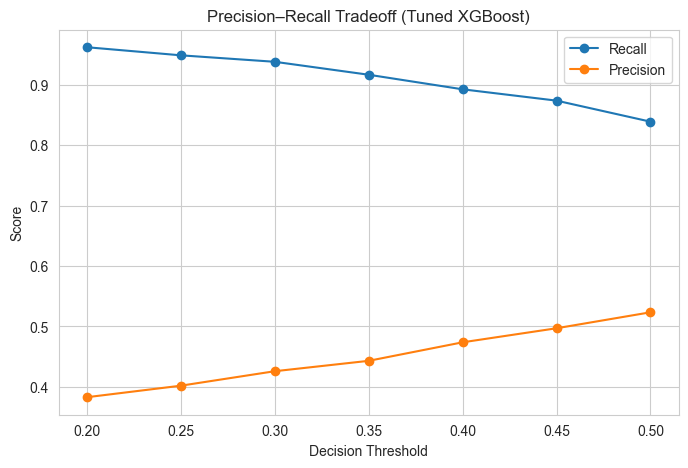

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Tradeoff (Tuned XGBoost)")
plt.legend()
plt.show()


In [129]:
final_threshold = 0.35

y_pred_final = (y_prob_tuned >= final_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Final Threshold:", final_threshold)
print(classification_report(y_test, y_pred_final))


Final Threshold: 0.35
              precision    recall  f1-score   support

           0       0.95      0.58      0.72      1036
           1       0.44      0.92      0.60       373

    accuracy                           0.67      1409
   macro avg       0.70      0.75      0.66      1409
weighted avg       0.82      0.67      0.69      1409



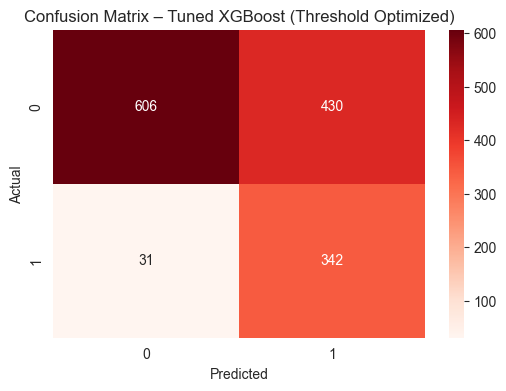

In [130]:
import seaborn as sns

cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Tuned XGBoost (Threshold Optimized)")
plt.show()


TN = 606   → correctly identified loyal customers
FP = 430   → loyal customers flagged as churn risk
FN = 31    → churners missed (VERY LOW)
TP = 342   → churners correctly caught


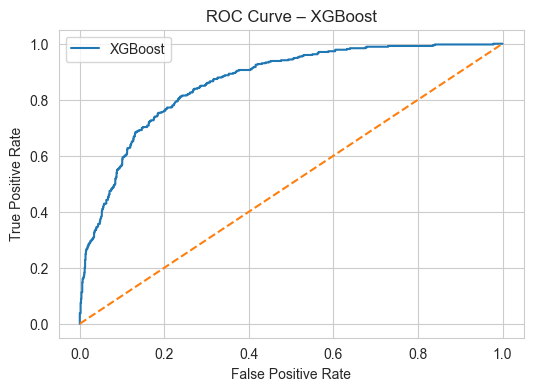

In [134]:
fpr, tpr, _ = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.show()


In [132]:
## Feature Importance & Key Churn Drivers

import pandas as pd

importance = pd.Series(
    best_xgb.feature_importances_,  # Changed from xgb to your model variable
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

Contract            0.299274
OnlineSecurity      0.166492
TechSupport         0.140174
InternetService     0.053600
tenure              0.042590
StreamingMovies     0.038234
PaperlessBilling    0.033555
MonthlyCharges      0.033105
OnlineBackup        0.028652
PaymentMethod       0.024911
dtype: float32


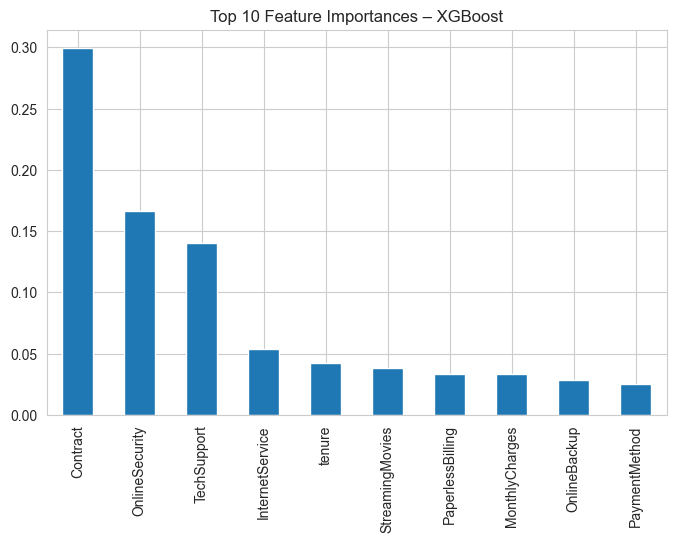

In [133]:
plt.figure(figsize=(8,5))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances – XGBoost")
plt.show()


### Key Observations
- Contract type is the most influential factor in churn prediction, indicating that customers on short-term contracts are more likely to churn.
- Customers lacking online security or technical support show significantly higher churn risk.
- Short-tenure customers and those with higher monthly charges are more likely to churn.


In [136]:
import os

os.makedirs("../models", exist_ok=True)


In [137]:
import joblib

# Save final model
joblib.dump(best_xgb, "../models/final_xgboost_churn_model.pkl")

# Save threshold separately
joblib.dump(final_threshold, "../models/churn_threshold.pkl")


['../models/churn_threshold.pkl']

FINAL Model Performance Summary

In [138]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

final_metrics = {
    "Model": "XGBoost (Tuned + Threshold)",
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision (Churn)": precision_score(y_test, y_pred_final),
    "Recall (Churn)": recall_score(y_test, y_pred_final),
    "F1-Score (Churn)": f1_score(y_test, y_pred_final),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned)
}

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df


,Model,Threshold,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),ROC-AUC
0,XGBoost (Tuned + Threshold),0.35,0.672818,0.443005,0.91689,0.59738,0.862638


In [139]:
comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Logistic Regression (Scaled + SMOTE)",
        "XGBoost (Tuned + Threshold)"
    ],
    "Recall (Churn)": [0.58, 0.53, 0.78, round(final_metrics["Recall (Churn)"], 2)],
    "ROC-AUC": [0.71, 0.86, 0.84, round(final_metrics["ROC-AUC"], 2)]
})

comparison_df


,Model,Recall (Churn),ROC-AUC
0,Random Forest,0.58,0.71
1,Gradient Boosting,0.53,0.86
2,Logistic Regression (Scaled + SMOTE),0.78,0.84
3,XGBoost (Tuned + Threshold),0.92,0.86


## Final Model Decision

The tuned XGBoost model with a decision threshold of 0.35 was selected as the final solution.
This configuration achieved high recall for churners, ensuring that the majority of at-risk
customers are identified proactively.

Although precision decreased slightly, this trade-off is acceptable since the cost of missing
a churner is significantly higher than offering retention incentives to loyal customers.


In [140]:
def predict_churn(model, threshold, X):
    probs = model.predict_proba(X)[:, 1]
    predictions = (probs >= threshold).astype(int)
    return predictions, probs


wrapped the trained model and the optimized threshold into a reusable prediction function
so that churn scoring can be consistently applied in production without retraining the model

## Conclusion

This project implemented an end-to-end machine learning pipeline for customer churn prediction.
Multiple models were evaluated, class imbalance was handled, hyperparameter and threshold tuning
were applied, and a business-aligned final model was selected.

The final XGBoost model successfully identifies nearly 92% of churners, enabling proactive
customer retention strategies and potential revenue savings.


In [142]:
import os

os.makedirs("../data/processed", exist_ok=True)


In [143]:
output_df.to_csv(
    "../data/processed/churn_predictions_for_powerbi.csv",
    index=False
)

print("File exported successfully for Power BI.")


File exported successfully for Power BI.


In [144]:
# ================================
# Export Predictions for Power BI
# ================================

import pandas as pd

# Create output dataframe
output_df = X_test.copy()

output_df['Actual_Churn'] = y_test
output_df['Churn_Probability'] = y_prob_tuned
output_df['Predicted_Churn'] = y_pred_final

# Optional: Risk category based on threshold
output_df['Risk_Category'] = output_df['Churn_Probability'].apply(
    lambda x: 'High' if x >= 0.6 else ('Medium' if x >= final_threshold else 'Low')
)

# Save to CSV for Power BI
output_df.to_csv("../data/processed/churn_predictions_for_powerbi.csv", index=False)

print("File exported successfully for Power BI.")


File exported successfully for Power BI.


In [149]:
import os
os.makedirs("../data/processed", exist_ok=True)

df_encoded.to_csv("../data/processed/X_full.csv", index=False)


In [151]:
import pandas as pd

# Load full encoded dataset
X_full = pd.read_csv("../data/processed/X_full.csv")

print("Full dataset shape:", X_full.shape)


Full dataset shape: (7043, 20)


In [153]:
# Drop target column if present
if "Churn" in X_full.columns:
    X_full = X_full.drop(columns=["Churn"])

print("Columns used for prediction:", X_full.columns.tolist())

Columns used for prediction: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [154]:
# Predict churn probabilities on full data
# Generate Predictions on FULL DATASET For power BI
full_probs = best_xgb.predict_proba(X_full)[:, 1]

# Apply final threshold
full_preds = (full_probs >= final_threshold).astype(int)


In [155]:
# Create Power BI output dataframe
output_full_df = X_full.copy()
output_full_df["Churn_Probability"] = full_probs
output_full_df["Predicted_Churn"] = full_preds

# Business-friendly risk buckets
output_full_df["Risk_Category"] = output_full_df["Churn_Probability"].apply(
    lambda x: "High" if x >= 0.6 else ("Medium" if x >= final_threshold else "Low")
)

# Export CSV
output_full_df.to_csv(
    "../data/processed/churn_predictions_full_for_powerbi.csv",
    index=False
)

print("✅ churn_predictions_full_for_powerbi.csv exported successfully")
print("Rows exported:", output_full_df.shape[0])

✅ churn_predictions_full_for_powerbi.csv exported successfully
Rows exported: 7043
